In [4]:
import scanpy as sc
import pandas as pd 
import seaborn as sns 
import random 
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import decoupler as dc
from datetime import datetime

In [5]:
adata = sc.read_h5ad('/data/peer/for_swanand/HTA.fresh_plasticity/adata_v4/adata.NSCLC_v4.h5ad')

In [6]:
exclude_samples =['RU581_Tb', 'RU581_Tc','RU581_LNc','RU581_LNb']
adata = adata[~adata.obs['sample'].isin(exclude_samples)].copy()
adata

AnnData object with n_obs × n_vars = 19310 × 26561
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'sample', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'RBP_frac', 'batch', 'patient', 'tissue', 'histo', 'ten_x_version', 'PDX', '_scvi_batch', '_scvi_labels', '_scvi_local_l_mean', '_scvi_local_l_var', 'phenograph', 'leiden', 'flag', 'keratins', 'EPCAM_cell', 'CDH1_cell', 'PTPRC_cell', 'VIM_cell', 'CLDN5_cell', 'PECAM1_cell', 'COL1A1_cell', 'COL1A2_cell', 'CHGA_cell', 'CHGB_cell', 'KRT7_cell', 'NAPSA_cell', 'NKX2-1_cell', 'KRT5_cell', 'KRT6A_cell', 'CD2_cell', 'CD3E_cell', 'MS4A1_cell', 'ITGAM_cell', 'ITGAX_cell', 'CD14_cell', 'TPSAB1_cell', 'HBA1_cell', 'ct_general', 'ct_old', 'empty_vs_rest', 'H_knn', 'cc_cell', 'SYP_cell', 'NCAM1_cell', 'ENO1_cell', 'ENO2_cell', 'STMN1_cell

In [7]:
# adata.X = adata.raw.X.copy()
# adata.layers['counts'] = adata.X.astype(int)

adata.X = adata.layers['counts'].copy()

In [8]:
df = pd.read_csv("/data/peer/for_swanand/ref/HTA.demographic.annotations.txt", sep='\t')

In [9]:
df['Date of Birth'] = pd.to_datetime(df['Date of Birth'], format='%m/%d/%y')
df['Date of Birth'] = df['Date of Birth'].apply(lambda x: x.replace(year=x.year - 100) if x.year > datetime.now().year else x)

df['Collection date'] = pd.to_datetime(df['Collection date'], format='%m/%d/%y')

# Calculate the difference in years
df['age'] = (df['Collection date'] - df['Date of Birth']).dt.days / 365.25
df

,Joe Abbreviation,Date of Birth,Sex,Race,Ethnicity,Smoking,Pack Years,Collection date,age
0,RU1144_T,1957-12-18,Female,White,Non Hispanic,former,70,2019-03-22,61.256674
1,RU1144_LN,1957-12-18,Female,White,Non Hispanic,former,70,2019-03-22,61.256674
2,RU9014_T,1943-05-21,Male,White,Non-Hispanic,former,44,2011-01-13,67.649555
3,RU9014_T,1943-05-21,Male,White,Non-Hispanic,former,44,2011-01-13,67.649555
4,RU9014_T,1943-05-21,Male,White,Non-Hispanic,former,44,2011-01-13,67.649555
...,...,...,...,...,...,...,...,...,...
89,RU831_PDX,1957-10-01,Female,White,Non Hispanic,never,0,2018-05-08,60.599589
90,RU871_PDX,1949-10-22,Male,White,Non Hispanic,former,45,2018-02-13,68.312115
91,RU942_ADR,1960-12-01,Male,Asian,Non Hispanic,never,0,2021-03-12,60.276523
92,RU942_LND,1960-12-01,Male,Asian,Non Hispanic,never,0,2021-11-04,60.925394


In [10]:

for index, row in df.iterrows():
    sample = row['Joe Abbreviation']
    adata.obs.loc[adata.obs['sample'] == sample, 'sex'] = row['Sex']
    adata.obs.loc[adata.obs['sample'] == sample, 'race'] = row['Race']
    adata.obs.loc[adata.obs['sample'] == sample, 'ethnicity'] = row['Ethnicity']
    adata.obs.loc[adata.obs['sample'] == sample, 'pack_years'] = row['Pack Years']
    adata.obs.loc[adata.obs['sample'] == sample, 'age'] = row['age']
    adata.obs.loc[adata.obs['sample'] == sample, 'smoking'] = row['Pack Years']!='0'
    adata.obs.loc[adata.obs['sample'] == sample, 'hispanic'] = row['Ethnicity']=='Spanish/Hispanic/Latino'
    adata.obs.loc[adata.obs['sample'] == sample, 'white'] = row['Race']=='White'
    adata.obs.loc[adata.obs['sample'] == sample, 'black'] = row['Race']=='Black'
    adata.obs.loc[adata.obs['sample'] == sample, 'asian'] = row['Race']=='Asian'
    adata.obs.loc[adata.obs['sample'] == sample, 'age_65_plus'] = int(row['age'])>=65


    



In [11]:
adata.obs[adata.obs['sample']=='RU1144_T']

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,log10GenesPerUMI,sample,...,race,ethnicity,pack_years,age,smoking,hispanic,white,black,asian,age_65_plus
RU1144_T_134539660971236,2581,7.856320,11099.0,9.314700,35.093252,51.103703,62.924588,75.087846,0.843399,RU1144_T,...,White,Non Hispanic,70,61.256674,True,False,True,False,False,False
RU1144_T_191645424704412,4175,8.337109,17487.0,9.769270,24.904215,34.059587,45.370847,61.439927,0.853382,RU1144_T,...,White,Non Hispanic,70,61.256674,True,False,True,False,False,False
RU1144_T_121826167671085,4804,8.477412,21684.0,9.984376,24.686405,33.388674,44.558200,60.242575,0.849051,RU1144_T,...,White,Non Hispanic,70,61.256674,True,False,True,False,False,False
RU1144_T_192745894427549,417,6.035481,644.0,6.469250,33.074534,48.602484,66.304348,100.000000,0.932803,RU1144_T,...,White,Non Hispanic,70,61.256674,True,False,True,False,False,False
RU1144_T_227425442711972,1718,7.449498,6079.0,8.712760,31.847343,44.283599,57.558809,75.374239,0.854959,RU1144_T,...,White,Non Hispanic,70,61.256674,True,False,True,False,False,False
RU1144_T_230654483819803,3972,8.287277,18555.0,9.828548,31.554837,42.091081,54.044732,67.836163,0.843163,RU1144_T,...,White,Non Hispanic,70,61.256674,True,False,True,False,False,False


## Never transformed triple mut LUAD vs Transformed LUAD_SCLC
###       design_factors=['chemo', 'IO', 'TKI','ten_x_version','PDX','smoking', 'hispanic','white','age_65_plus', 'Pre-transformed'],



In [23]:
cell_subset = adata[adata.obs['Pre-transformed']!='Normal']
cell_subset = cell_subset[cell_subset.obs['histo'].isin(['LUAD', 'LUAD_SCLC'])]
cell_subset = cell_subset[cell_subset.obs['sclc_cells']=='False']
cell_subset.X = cell_subset.layers['counts']

In [24]:
pdata = dc.get_pseudobulk(
    cell_subset,
    sample_col='sample',
    groups_col=None,
    layer='norm',
    mode='sum',
    min_cells=10,
    min_counts=1000
)


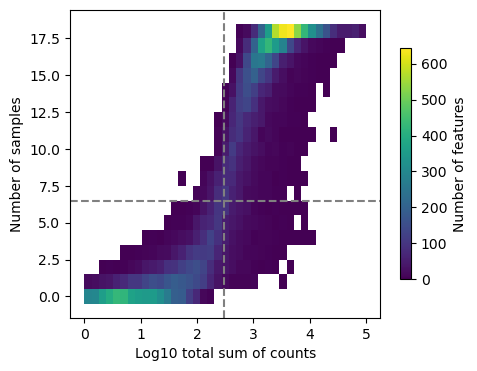

In [25]:
dc.plot_filter_by_expr(pdata, group='Pre-transformed', min_count=5, min_total_count=300)

In [26]:
genes = dc.filter_by_expr(pdata, group='Pre-transformed', min_count=5, min_total_count=300)
pdata = pdata[:, genes].copy()
pdata


AnnData object with n_obs × n_vars = 18 × 11329
    obs: 'sample', 'batch', 'patient', 'tissue', 'histo', 'ten_x_version', 'PDX', '_scvi_batch', '_scvi_labels', '_scvi_local_l_mean', '_scvi_local_l_var', 'PTPRC_cell', 'PECAM1_cell', 'KRT5_cell', 'CD2_cell', 'CD3E_cell', 'MS4A1_cell', 'ITGAX_cell', 'CD14_cell', 'TPSAB1_cell', 'HBA1_cell', 'ct_general', 'NEUROD2_cell', 'POU2F3_cell', 'clusters_normal', 'normal_cells', 'Type', 'sclc_cells', 'cell_type', 'Pre-transformed', 'POsIE', 'chemo', 'IO', 'TKI', 'sex', 'race', 'ethnicity', 'pack_years', 'age', 'smoking', 'hispanic', 'white', 'black', 'asian', 'age_65_plus', 'psbulk_n_cells', 'psbulk_counts'
    layers: 'psbulk_props'

In [27]:
dds = DeseqDataSet(
    adata = pdata,
    design_factors=['chemo', 'IO', 'TKI','ten_x_version','PDX','smoking', 'hispanic','white','age_65_plus', 'Pre-transformed'],
    ref_level=['Pre-transformed', 'Triple_mutant_LUAD'],
    refit_cooks=True,
)


ValueError: The count matrix should only contain integers.

In [18]:
dds.deseq2()


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 2.10 seconds.

Fitting dispersion trend curve...
... done in 3.76 seconds.

Fitting MAP dispersions...
... done in 2.02 seconds.

Fitting LFCs...
... done in 1.20 seconds.

Refitting 5414 outliers.

Fitting dispersions...
... done in 0.73 seconds.

Fitting MAP dispersions...
... done in 0.74 seconds.

Fitting LFCs...
... done in 0.83 seconds.



In [19]:
stat_res = DeseqStats(dds, contrast=["Pre-transformed", 'Pre_transformed_NSCLC', 'Triple_mutant_LUAD'], n_cpus=8)
stat_res.summary()

Running Wald tests...
... done in 17.61 seconds.

Log2 fold change & Wald test p-value: Pre-transformed Pre_transformed_NSCLC vs Triple_mutant_LUAD


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
A1BG,45.040100,-0.694186,0.579501,-1.197903,0.230955,0.997401
A2M,6.991483,-0.042390,1.973127,-0.021484,0.982860,0.997662
A2ML1,49.024063,-1.718887,1.365398,-1.258890,0.208070,0.997401
A4GALT,16.210670,0.088237,0.839985,0.105046,0.916340,0.997401
AAAS,25.888712,-0.070358,0.491832,-0.143053,0.886249,0.997401
...,...,...,...,...,...,...
ZXDC,24.547295,-0.398902,1.582009,-0.252149,0.800926,0.997401
ZYG11B,35.892967,-0.581305,0.465921,-1.247647,0.212160,0.997401
ZYX,70.340309,-0.615715,0.491340,-1.253135,0.210157,0.997401
ZZEF1,17.551535,1.322406,0.572170,2.311211,0.020821,0.997401


In [20]:
# stat_res.lfc_shrink(coeff='Pre-transformed_Pre_transformed_NSCLC_vs_Triple_mutant_LUAD')

In [21]:
results_df = stat_res.results_df
results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
A1BG,45.040100,-0.694186,0.579501,-1.197903,0.230955,0.997401
A2M,6.991483,-0.042390,1.973127,-0.021484,0.982860,0.997662
A2ML1,49.024063,-1.718887,1.365398,-1.258890,0.208070,0.997401
A4GALT,16.210670,0.088237,0.839985,0.105046,0.916340,0.997401
AAAS,25.888712,-0.070358,0.491832,-0.143053,0.886249,0.997401
...,...,...,...,...,...,...
ZXDC,24.547295,-0.398902,1.582009,-0.252149,0.800926,0.997401
ZYG11B,35.892967,-0.581305,0.465921,-1.247647,0.212160,0.997401
ZYX,70.340309,-0.615715,0.491340,-1.253135,0.210157,0.997401
ZZEF1,17.551535,1.322406,0.572170,2.311211,0.020821,0.997401


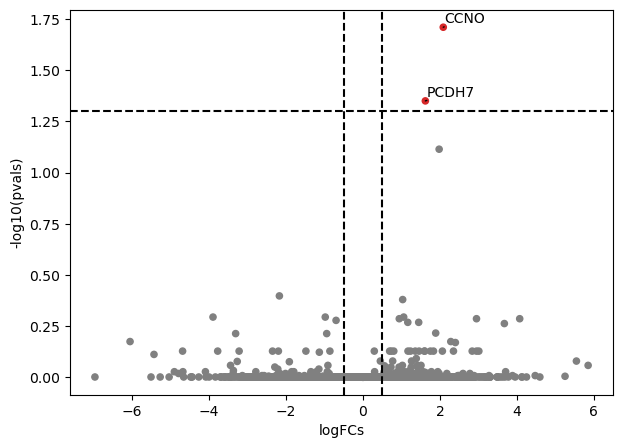

In [22]:
dc.plot_volcano_df(results_df, x='log2FoldChange', y='padj', top=20, save = 'NSCLC_DEG/volcano_tripmutLUAD_T-LUAD_DEG_pb_demo_v4.png')


In [20]:
results_df.to_csv('NSCLC_DEG/tripmutLUAD_T-LUAD_DEG_pb_demo_v4.csv')

## Never transformed triple mut LUAD vs Transformed LUAD
###       design_factors=    design_factors=['chemo', 'IO', 'TKI','ten_x_version','PDX','Pre-transformed']

In [84]:
cell_subset = adata[adata.obs['Pre-transformed']!='Normal']
cell_subset = cell_subset[cell_subset.obs['histo'].isin(['LUAD', 'LUAD_SCLC'])]
cell_subset = cell_subset[cell_subset.obs['sclc_cells']=='False']
cell_subset.X = cell_subset.layers['counts']

In [85]:
pdata = dc.get_pseudobulk(
    cell_subset,
    sample_col='sample',
    groups_col=None,
    layer='counts',
    mode='sum',
    min_cells=10,
    min_counts=1000
)

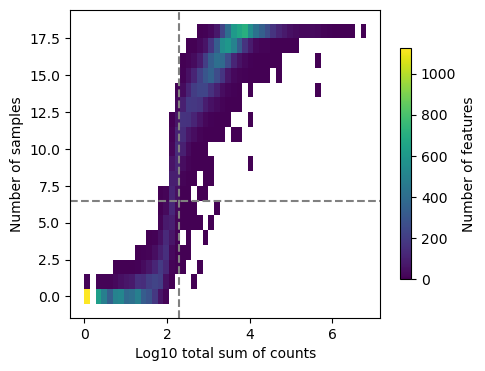

In [87]:
dc.plot_filter_by_expr(pdata, group='Pre-transformed', min_count=2, min_total_count=200)

In [88]:
genes = dc.filter_by_expr(pdata, group='Pre-transformed', min_count=2, min_total_count=200)
pdata = pdata[:, genes].copy()
pdata

AnnData object with n_obs × n_vars = 18 × 14260
    obs: 'sample', 'batch', 'patient', 'tissue', 'histo', 'ten_x_version', 'PDX', '_scvi_batch', '_scvi_labels', '_scvi_local_l_mean', '_scvi_local_l_var', 'PTPRC_cell', 'PECAM1_cell', 'KRT5_cell', 'CD2_cell', 'CD3E_cell', 'MS4A1_cell', 'ITGAX_cell', 'CD14_cell', 'TPSAB1_cell', 'HBA1_cell', 'ct_general', 'NEUROD2_cell', 'POU2F3_cell', 'clusters_normal', 'normal_cells', 'Type', 'sclc_cells', 'cell_type', 'Pre-transformed', 'POsIE', 'chemo', 'IO', 'TKI', 'sex', 'race', 'ethnicity', 'pack_years', 'age', 'smoking', 'hispanic', 'white', 'black', 'asian', 'age_65_plus', 'psbulk_n_cells', 'psbulk_counts'
    layers: 'psbulk_props'

In [90]:
dds = DeseqDataSet(
    adata = pdata,
    design_factors=['chemo', 'IO', 'TKI','ten_x_version','PDX','Pre-transformed'],
    ref_level=['Pre-transformed', 'Triple_mutant_LUAD'],
    refit_cooks=True,
)


In [91]:
dds.deseq2()

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 26.48 seconds.

Fitting dispersion trend curve...
... done in 3.36 seconds.

Fitting MAP dispersions...
... done in 23.97 seconds.

Fitting LFCs...
... done in 3.45 seconds.

Refitting 8246 outliers.

Fitting dispersions...
... done in 2.38 seconds.

Fitting MAP dispersions...
... done in 2.27 seconds.

Fitting LFCs...
... done in 1.81 seconds.



In [92]:
stat_res = DeseqStats(dds, contrast=["Pre-transformed", 'Pre_transformed_NSCLC','Triple_mutant_LUAD'], n_cpus=8)
stat_res.summary()

Running Wald tests...
... done in 18.03 seconds.

Log2 fold change & Wald test p-value: Pre-transformed Pre_transformed_NSCLC vs Triple_mutant_LUAD


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
A1BG,44.239994,0.034389,0.155329,0.221395,0.824785,0.999721
A2M,6.991483,-0.381280,0.479036,-0.795932,0.426072,0.999721
A2ML1,49.024063,0.040970,0.405652,0.100998,0.919552,0.999721
A4GALT,16.210670,0.018864,0.121748,0.154939,0.876870,0.999721
AAAS,25.888712,-0.094710,0.101705,-0.931225,0.351737,0.999721
...,...,...,...,...,...,...
ZXDC,24.547295,0.172254,0.363184,0.474289,0.635294,0.999721
ZYG11B,35.937420,-0.098545,0.083527,-1.179806,0.238077,0.999721
ZYX,70.340309,-0.022925,0.104232,-0.219943,0.825915,0.999721
ZZEF1,17.551535,-0.048215,0.079134,-0.609280,0.542339,0.999721


In [93]:
# stat_res.lfc_shrink(coeff='Pre-transformed_Pre_transformed_NSCLC_vs_Triple_mutant_LUAD')

In [94]:
results_df = stat_res.results_df
results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
A1BG,44.239994,0.034389,0.155329,0.221395,0.824785,0.999721
A2M,6.991483,-0.381280,0.479036,-0.795932,0.426072,0.999721
A2ML1,49.024063,0.040970,0.405652,0.100998,0.919552,0.999721
A4GALT,16.210670,0.018864,0.121748,0.154939,0.876870,0.999721
AAAS,25.888712,-0.094710,0.101705,-0.931225,0.351737,0.999721
...,...,...,...,...,...,...
ZXDC,24.547295,0.172254,0.363184,0.474289,0.635294,0.999721
ZYG11B,35.937420,-0.098545,0.083527,-1.179806,0.238077,0.999721
ZYX,70.340309,-0.022925,0.104232,-0.219943,0.825915,0.999721
ZZEF1,17.551535,-0.048215,0.079134,-0.609280,0.542339,0.999721


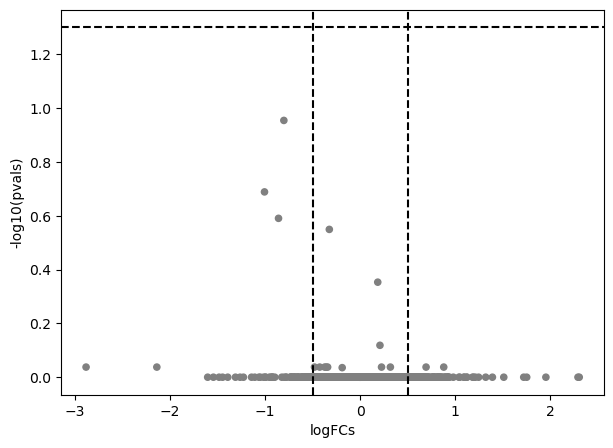

In [95]:
dc.plot_volcano_df(results_df, x='log2FoldChange', y='padj', top=20, save = 'NSCLC_DEG/volcano_tripmutLUAD_T-LUAD_DEG_v4.png')


In [30]:
results_df.to_csv('NSCLC_DEG/tripmutLUAD_T-LUAD_DEG_v4.csv')

## LUAD_SCLC vs LUSC_SCLC
### design_factors=['chemo', 'IO', 'TKI','ten_x_version','PDX','histo']

In [69]:
# cell_subset = adata[adata.obs['Pre-transformed']!='Normal']
cell_subset = adata[adata.obs['histo'].isin(['LUSC_SCLC', 'LUAD_SCLC'])]
# cell_subset = cell_subset[cell_subset.obs['Pre-transformed']!='Normal']
cell_subset = cell_subset[cell_subset.obs['sclc_cells']=='False']
cell_subset.X = cell_subset.layers['counts']

In [70]:
cell_subset.obs['PDX']

RU1250_T1_226331299530996    None
RU831_PDX_134377510985115     PDX
RU1083_T1_165397793459547    None
RU1250_T2_231151760952539    None
RU1250_PL_135546843096996    None
                             ... 
RU1250_PL_227905839225062    None
RU1303_T_200923761822557     None
RU1250_T2_166402827697462    None
RU1303_LN_156598242307380    None
RU942_ADR_200502424759724    None
Name: PDX, Length: 6946, dtype: category
Categories (2, object): ['None', 'PDX']

In [71]:
pdata = dc.get_pseudobulk(
    cell_subset,
    sample_col='sample',
    groups_col=None,
    layer='counts',
    mode='sum',
    min_cells=10,
    min_counts=1000
)

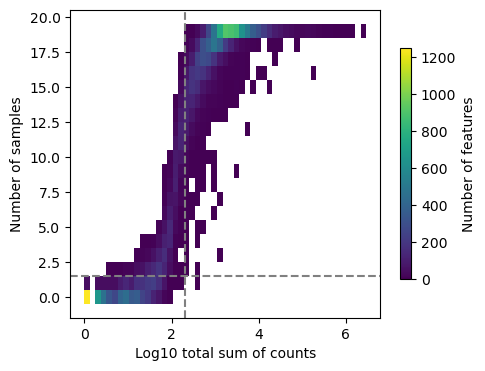

In [73]:
dc.plot_filter_by_expr(pdata, group='histo', min_count =2, min_total_count=200)

In [74]:
genes = dc.filter_by_expr(pdata, group='histo', min_count=2, min_total_count=200)
pdata = pdata[:, genes].copy()
pdata

AnnData object with n_obs × n_vars = 19 × 12688
    obs: 'sample', 'batch', 'patient', 'tissue', 'histo', 'ten_x_version', 'PDX', '_scvi_batch', '_scvi_labels', '_scvi_local_l_mean', '_scvi_local_l_var', 'PTPRC_cell', 'CLDN5_cell', 'PECAM1_cell', 'CHGA_cell', 'CHGB_cell', 'KRT5_cell', 'CD2_cell', 'CD3E_cell', 'MS4A1_cell', 'ITGAM_cell', 'ITGAX_cell', 'CD14_cell', 'TPSAB1_cell', 'HBA1_cell', 'ct_general', 'SYP_cell', 'NCAM1_cell', 'ENO1_cell', 'ENO2_cell', 'ASCL1_cell', 'ASCL2_cell', 'NEUROD2_cell', 'NEUROD4_cell', 'POU2F3_cell', 'NE', 'normal_cells', 'Type', 'sclc_cells', 'POsIE', 'chemo', 'IO', 'TKI', 'sex', 'race', 'ethnicity', 'pack_years', 'age', 'smoking', 'hispanic', 'white', 'black', 'asian', 'age_65_plus', 'psbulk_n_cells', 'psbulk_counts'
    layers: 'psbulk_props'

In [76]:
dds = DeseqDataSet(
    adata = pdata,
    design_factors=['chemo','IO','TKI','tissue','ten_x_version','histo'],
    ref_level=['histo', 'LUAD_SCLC'],
    refit_cooks=True,
)


In [77]:
dds.deseq2()

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 27.50 seconds.

Fitting dispersion trend curve...
... done in 3.02 seconds.

Fitting MAP dispersions...
... done in 23.70 seconds.

Fitting LFCs...
... done in 2.54 seconds.

Refitting 5716 outliers.

Fitting dispersions...
... done in 1.53 seconds.

Fitting MAP dispersions...
... done in 1.78 seconds.

Fitting LFCs...
... done in 1.47 seconds.



In [78]:
stat_res = DeseqStats(dds, contrast=["histo", 'LUSC_SCLC','LUAD_SCLC'], n_cpus=8)
stat_res.summary()

Running Wald tests...
... done in 18.06 seconds.

Log2 fold change & Wald test p-value: histo LUSC_SCLC vs LUAD_SCLC


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
A1BG,35.843784,-1.150813,0.853688,-1.348049,0.177643,0.595246
A2M,3.421755,3.660121,4.322442,0.846771,0.397122,NaN
A2ML1,38.229084,-0.452134,0.934163,-0.483999,0.628386,0.886382
A4GALT,14.808551,3.544319,1.866578,1.898833,0.057586,NaN
AAAS,17.826881,-1.691801,1.141948,-1.481504,0.138472,NaN
...,...,...,...,...,...,...
ZXDC,15.735870,0.909618,1.419127,0.640970,0.521542,NaN
ZYG11B,27.741198,-0.368571,0.832205,-0.442885,0.657849,NaN
ZYX,49.864189,0.476135,1.178117,0.404149,0.686103,0.902935
ZZEF1,12.568866,1.305937,1.582328,0.825327,0.409186,NaN


In [79]:
# stat_res.lfc_shrink(coeff='histo_LUSC_SCLC_vs_LUAD_SCLC')

In [80]:
results_df = stat_res.results_df
results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
A1BG,35.843784,-1.150813,0.853688,-1.348049,0.177643,0.595246
A2M,3.421755,3.660121,4.322442,0.846771,0.397122,NaN
A2ML1,38.229084,-0.452134,0.934163,-0.483999,0.628386,0.886382
A4GALT,14.808551,3.544319,1.866578,1.898833,0.057586,NaN
AAAS,17.826881,-1.691801,1.141948,-1.481504,0.138472,NaN
...,...,...,...,...,...,...
ZXDC,15.735870,0.909618,1.419127,0.640970,0.521542,NaN
ZYG11B,27.741198,-0.368571,0.832205,-0.442885,0.657849,NaN
ZYX,49.864189,0.476135,1.178117,0.404149,0.686103,0.902935
ZZEF1,12.568866,1.305937,1.582328,0.825327,0.409186,NaN


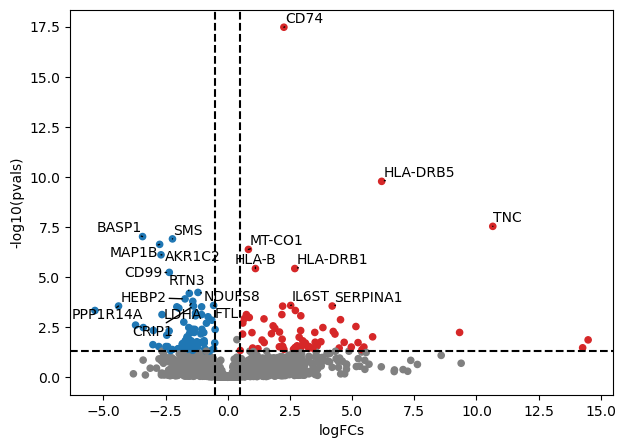

In [81]:
dc.plot_volcano_df(results_df, x='log2FoldChange', y='padj', top=20, save ='NSCLC_DEG/volcano_LAUD_SCLC_LUSC_SCLC_v4.png')


In [82]:
results_df.to_csv('NSCLC_DEG/LAUD_SCLC_LUSC_SCLC_v4.csv')

## LUAD_SCLC vs LUSC_SCLC
###     design_factors=['chemo','TKI','ten_x_version','age_65_plus','hispanic','histo'],

In [43]:
# cell_subset = adata[adata.obs['Pre-transformed']!='Normal']
cell_subset = adata[adata.obs['histo'].isin(['LUSC_SCLC', 'LUAD_SCLC'])]
# cell_subset = cell_subset[cell_subset.obs['Pre-transformed']!='Normal']
cell_subset = cell_subset[cell_subset.obs['sclc_cells']=='False']
cell_subset.X = cell_subset.layers['counts']

In [44]:
pdata = dc.get_pseudobulk(
    cell_subset,
    sample_col='sample',
    groups_col=None,
    layer='counts',
    mode='sum',
    min_cells=50,
    min_counts=1500
)

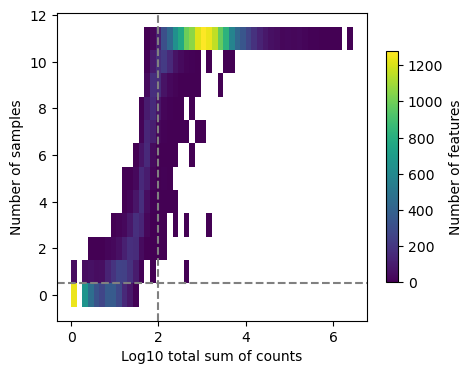

In [45]:
dc.plot_filter_by_expr(pdata, group='histo', min_count =2, min_total_count=100)

In [46]:
genes = dc.filter_by_expr(pdata, group='histo', min_count=2, min_total_count=100)
pdata = pdata[:, genes].copy()
pdata

AnnData object with n_obs × n_vars = 11 × 14030
    obs: 'sample', 'batch', 'patient', 'tissue', 'histo', 'ten_x_version', 'PDX', '_scvi_batch', '_scvi_labels', '_scvi_local_l_mean', '_scvi_local_l_var', 'PTPRC_cell', 'CLDN5_cell', 'PECAM1_cell', 'CHGA_cell', 'CHGB_cell', 'KRT5_cell', 'CD2_cell', 'CD3E_cell', 'MS4A1_cell', 'ITGAM_cell', 'ITGAX_cell', 'CD14_cell', 'TPSAB1_cell', 'HBA1_cell', 'ct_general', 'SYP_cell', 'NCAM1_cell', 'ENO1_cell', 'ENO2_cell', 'ASCL1_cell', 'ASCL2_cell', 'NEUROD2_cell', 'NEUROD4_cell', 'POU2F3_cell', 'NE', 'normal_cells', 'Type', 'sclc_cells', 'POsIE', 'chemo', 'IO', 'TKI', 'sex', 'race', 'ethnicity', 'pack_years', 'age', 'smoking', 'hispanic', 'white', 'black', 'asian', 'age_65_plus', 'psbulk_n_cells', 'psbulk_counts'
    layers: 'psbulk_props'

In [47]:
dds = DeseqDataSet(
    adata = pdata,
    design_factors=['chemo','TKI','ten_x_version','age_65_plus','hispanic','histo'],
    ref_level=['histo', 'LUAD_SCLC'],
    refit_cooks=True,
)


In [48]:
dds.deseq2()

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 22.43 seconds.

Fitting dispersion trend curve...
... done in 3.35 seconds.

Fitting MAP dispersions...
... done in 18.91 seconds.

Fitting LFCs...
... done in 2.12 seconds.

Refitting 1210 outliers.

Fitting dispersions...
... done in 0.58 seconds.

Fitting MAP dispersions...
... done in 0.56 seconds.

Fitting LFCs...
... done in 0.53 seconds.



In [49]:
stat_res = DeseqStats(dds, contrast=["histo", 'LUSC_SCLC','LUAD_SCLC'], n_cpus=8)
stat_res.summary()

Running Wald tests...
... done in 18.29 seconds.

Log2 fold change & Wald test p-value: histo LUSC_SCLC vs LUAD_SCLC


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
A1BG,116.330330,-0.239736,0.471388,-0.508574,0.611051,0.999949
A2M,18.769239,0.691621,1.482704,0.466459,0.640887,0.999949
A2ML1,115.199783,0.940913,0.313489,3.001419,0.002687,0.586419
A4GALT,53.789639,0.597855,0.644081,0.928230,0.353288,0.999949
AAAS,53.084499,0.356265,0.499705,0.712951,0.475876,0.999949
...,...,...,...,...,...,...
ZXDC,49.267761,0.681187,0.722295,0.943087,0.345636,0.999949
ZYG11B,96.709740,0.761827,0.419879,1.814398,0.069616,0.999949
ZYX,166.580856,0.084135,0.231794,0.362974,0.716624,0.999949
ZZEF1,44.880543,-0.171123,0.436272,-0.392240,0.694881,0.999949


In [50]:
# stat_res.lfc_shrink(coeff='histo_LUSC_SCLC_vs_LUAD_SCLC')

In [51]:
results_df = stat_res.results_df
results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
A1BG,116.330330,-0.239736,0.471388,-0.508574,0.611051,0.999949
A2M,18.769239,0.691621,1.482704,0.466459,0.640887,0.999949
A2ML1,115.199783,0.940913,0.313489,3.001419,0.002687,0.586419
A4GALT,53.789639,0.597855,0.644081,0.928230,0.353288,0.999949
AAAS,53.084499,0.356265,0.499705,0.712951,0.475876,0.999949
...,...,...,...,...,...,...
ZXDC,49.267761,0.681187,0.722295,0.943087,0.345636,0.999949
ZYG11B,96.709740,0.761827,0.419879,1.814398,0.069616,0.999949
ZYX,166.580856,0.084135,0.231794,0.362974,0.716624,0.999949
ZZEF1,44.880543,-0.171123,0.436272,-0.392240,0.694881,0.999949


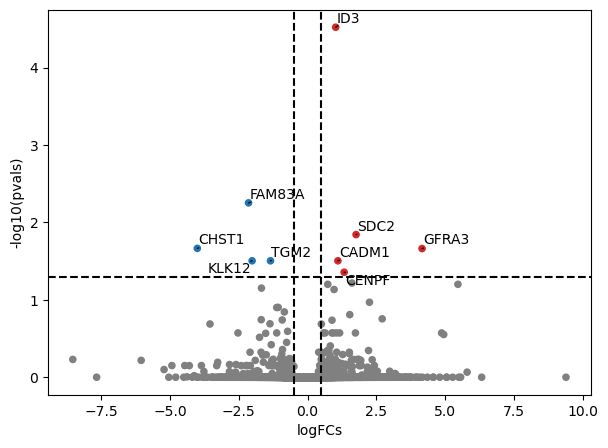

In [52]:
dc.plot_volcano_df(results_df, x='log2FoldChange', y='padj', top=20, save ='NSCLC_DEG/volcano_LAUD_SCLC_LUSC_SCLC_demo_v4.png')


In [53]:
results_df.to_csv('NSCLC_DEG/LAUD_SCLC_LUSC_SCLC_demo_v4.csv')

In [54]:
adata

AnnData object with n_obs × n_vars = 19310 × 26561
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'sample', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'RBP_frac', 'batch', 'patient', 'tissue', 'histo', 'ten_x_version', 'PDX', '_scvi_batch', '_scvi_labels', '_scvi_local_l_mean', '_scvi_local_l_var', 'phenograph', 'leiden', 'flag', 'keratins', 'EPCAM_cell', 'CDH1_cell', 'PTPRC_cell', 'VIM_cell', 'CLDN5_cell', 'PECAM1_cell', 'COL1A1_cell', 'COL1A2_cell', 'CHGA_cell', 'CHGB_cell', 'KRT7_cell', 'NAPSA_cell', 'NKX2-1_cell', 'KRT5_cell', 'KRT6A_cell', 'CD2_cell', 'CD3E_cell', 'MS4A1_cell', 'ITGAM_cell', 'ITGAX_cell', 'CD14_cell', 'TPSAB1_cell', 'HBA1_cell', 'ct_general', 'ct_old', 'empty_vs_rest', 'H_knn', 'cc_cell', 'SYP_cell', 'NCAM1_cell', 'ENO1_cell', 'ENO2_cell', 'STMN1_cell

In [55]:
import numpy as np
np.max(adata.X)

18219.0

In [56]:
np.max(adata.layers['norm'])

13.759083